In [3]:
%reset -f


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import ee
ee.Authenticate()


True

In [ ]:

from datetime import datetime as dt
from datetime import timedelta
import pandas as pd
import requests
import os

infoFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/New_GHCN_Station_Info.csv'
dataLINK = 'https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access'
outFOLDER = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/ghcn_download'

dates = []
start_date = dt(1984, 1, 1, 0, 0)
end_date = dt(2013, 12, 31, 0, 0)
date = start_date
while date <= end_date:
  dates.append(date)
  date = date + timedelta(days=1)

keepers = ['USW00003103', 'USC00102444', 'USC00244345', 'USC00325479', 'USC00394184', 'USC00256200', 'USW00024022', 'USC00053553', 'USW00023185', 'USC00423097']
pt_labels = ['flagstaff', 'deerflat', 'billings', 'bismark', 'badlands', 'ogallala', 'laramie', 'greeley', 'reno', 'greatsaltlake']

i = 0
done = False
while done == False:

  keeper = keepers[i]
  print(keeper)
  df = pd.DataFrame()
  df.index.name = 'index'
  df['year'] = [date.year for date in dates]
  df['month'] = [date.month for date in dates]
  df['day'] = [date.day for date in dates]
  df[keeper] = [0.0 for date in dates]

  outFILE = os.path.join(outFOLDER, pt_labels[i] + '.csv')
  url = dataLINK + '/' + keeper + '.csv'
  req = requests.get(url)
  text = req.text
  if not '404 Not Found' in text:

    lines = [line for line in text.splitlines()]
    hdrs = lines[0].split(',')
    prcp_col_i = hdrs.index('"PRCP"')
    date_col_i = hdrs.index('"DATE"')

    for line in lines[1:]:
      row = line.split('","')
      name_no_comma = row[5].replace(',', '')
      line = line.replace(row[5], name_no_comma)
      line = line.replace('","', ',')
      row = line.split(',')
      lon = row[3]
      lat = row[2]
      date = dt.strptime(row[date_col_i].strip('"'), '%Y-%m-%d')
      prcp = row[prcp_col_i].strip('"')

      if date.year >= 1984 and date.year <= 2013:

        if prcp != '' and not any([s in prcp for s in ['P', 'T', 'H', '9999']]):
          prcp = float(prcp)/10.0
          df.loc[(df['year'] == date.year) & (df['month']==date.month) & (df['day']==date.day), keeper] = prcp

  i += 1

  if i == len(keepers):
    done = True

  df.to_csv(outFILE)


USW00003103
USC00102444
USC00244345
USC00325479
USC00394184
USC00256200
USW00024022
USC00053553
USW00023185
USC00423097


In [ ]:
import ee

ee.Initialize(project='ee-andrewfullhart')

infoFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/GHCNd_RHEMSNOW.txt'

coords = []
with open(infoFILE) as f:
  next(f)
  for line in f:
    lon = float(line.split(',')[3])
    lat = float(line.split(',')[4])
    coords.append([lon, lat])

#Units are in mm for all datasets
#ee.ImageCollection('NASA/ORNL/DAYMET_V4') //prcp
#ee.ImageCollection('OREGONSTATE/PRISM/AN81d') //ppt
#ee.ImageCollection('IDAHO_EPSCOR/GRIDMET') //pr
#ee.ImageCollection('IDAHO_EPSCOR/MACAv2_METDATA') //pr

dataset = ee.ImageCollection('OREGONSTATE/PRISM/AN81d')                         \
            .filter(ee.Filter.date('1983-12-31', '2013-12-31'))

product = 'prism'
ic = dataset

flagstaff = ee.Geometry.Point(coords[0][0], coords[0][1])
deerflat = ee.Geometry.Point(coords[1][0], coords[1][1])
billings = ee.Geometry.Point(coords[2][0], coords[2][1])
bismark = ee.Geometry.Point(coords[3][0], coords[3][1])
badlands = ee.Geometry.Point(coords[4][0], coords[4][1])
ogallala = ee.Geometry.Point(coords[5][0], coords[5][1])
laramie = ee.Geometry.Point(coords[6][0], coords[6][1])
greeley = ee.Geometry.Point(coords[7][0], coords[7][1])
reno = ee.Geometry.Point(coords[8][0], coords[8][1])
greatsaltlake = ee.Geometry.Point(coords[9][0], coords[9][1])


points = ee.List([flagstaff, deerflat, billings, bismark, badlands, ogallala, laramie, greeley, reno, greatsaltlake])
pt_labels = ['flagstaff', 'deerflat', 'billings', 'bismark', 'badlands', 'ogallala', 'laramie', 'greeley', 'reno', 'greatsaltlake']


for i in range(10):

  point = ee.Geometry(points.get(i))
  station = pt_labels[i]
  print(station)
  prop_list = ic.getRegion(point, 500)

  def props_fn(props):
    props = ee.List(props)
    return ee.Feature(None, {'date':props.get(0), 'tmin':props.get(6), 'tmax':props.get(7), 'tdew':props.get(8)})

  tableFeat = ee.FeatureCollection(prop_list.slice(1).map(props_fn))

  task = ee.batch.Export.table.toDrive(
          collection = tableFeat,
          description='{}_{}'.format(station, product),
          folder='GEE_Downloads',
          selectors=['date', 'tmax', 'tmin', 'tdew'])

  task.start()



flagstaff
deerflat
billings
bismark
badlands
ogallala
laramie
greeley
reno
greatsaltlake


In [ ]:
import ee

ee.Initialize(project='ee-andrewfullhart')

infoFILE = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/GHCNd_RHEMSNOW.txt'

coords = []
with open(infoFILE) as f:
  next(f)
  for line in f:
    lon = float(line.split(',')[3])
    lat = float(line.split(',')[4])
    coords.append([lon, lat])

#Units are in mm for all datasets
#ee.ImageCollection('NASA/ORNL/DAYMET_V4') //prcp
#ee.ImageCollection('OREGONSTATE/PRISM/AN81d') //ppt
#ee.ImageCollection('IDAHO_EPSCOR/GRIDMET') //pr
#ee.ImageCollection('IDAHO_EPSCOR/MACAv2_METDATA') //pr

dataset = ee.ImageCollection('NASA/ORNL/DAYMET_V4')                             \
            .filter(ee.Filter.date('1984-01-01', '2014-01-01'))

product = 'daymet'
ic = dataset

flagstaff = ee.Geometry.Point(coords[0][0], coords[0][1])
deerflat = ee.Geometry.Point(coords[1][0], coords[1][1])
billings = ee.Geometry.Point(coords[2][0], coords[2][1])
bismark = ee.Geometry.Point(coords[3][0], coords[3][1])
badlands = ee.Geometry.Point(coords[4][0], coords[4][1])
ogallala = ee.Geometry.Point(coords[5][0], coords[5][1])
laramie = ee.Geometry.Point(coords[6][0], coords[6][1])
greeley = ee.Geometry.Point(coords[7][0], coords[7][1])
reno = ee.Geometry.Point(coords[8][0], coords[8][1])
greatsaltlake = ee.Geometry.Point(coords[9][0], coords[9][1])


points = ee.List([flagstaff, deerflat, billings, bismark, badlands, ogallala, laramie, greeley, reno, greatsaltlake])
pt_labels = ['flagstaff', 'deerflat', 'billings', 'bismark', 'badlands', 'ogallala', 'laramie', 'greeley', 'reno', 'greatsaltlake']


for i in range(10):

  point = ee.Geometry(points.get(i))
  station = pt_labels[i]
  prop_list = ic.getRegion(point, 500)
  def props_fn(props):
    props = ee.List(props)
    return ee.Feature(None, {'date':props.get(0), 'dayl':props.get(4), 'srad':props.get(6)})

  tableFeat = ee.FeatureCollection(prop_list.slice(1).map(props_fn))

  task = ee.batch.Export.table.toDrive(
          collection = tableFeat,
          description='{}_{}'.format(station, product),
          folder='GEE_Downloads',
          selectors=['date', 'dayl', 'srad'])

  task.start()



In [ ]:
import os
import pandas as pd
import numpy as np

header = 'Year,Month,Day,Precip(in),Max(F),Min(F),Dew(F),Solrad(L)'
ghcn = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/ghcn_download'
prism = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/prism_download'
daymet = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/daymet_download'
outfolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/input_data_to_pars'

files = os.listdir(ghcn)
for i, ff in enumerate(files):
  files = os.listdir(ghcn)
  ffile = files[i]
  with open(os.path.join(ghcn, ffile)) as f:
    lines = f.readlines()
  year, month, day, precip = [], [], [], []
  for line in lines[1:]:
    row = line.strip('\n').split(',')
    year.append(row[1])
    month.append(row[2])
    day.append(row[3])
    precip.append(float(row[4])/25.4)


  files = os.listdir(prism)
  ffile = files[i]
  with open(os.path.join(prism, ffile)) as f:
    lines = f.readlines()
  date, tmax, tmin, tdew = [], [], [], []
  for line in lines[1:]:
    row = line.strip('\n').split(',')
    date.append(row[0])
    tmax.append(float(row[1])*(9.0/5.0)+32)
    tmin.append(float(row[2])*(9.0/5.0)+32)
    tdew.append(float(row[3])*(9.0/5.0)+32)


  files = os.listdir(daymet)
  ffile = files[i]
  with open(os.path.join(daymet, ffile)) as f:
    lines = f.readlines()
  dayl, srad = [], []
  lastdayl = float(lines[1].strip('\n').split(',')[1])
  lastsrad = float(lines[1].strip('\n').split(',')[2])*lastdayl/41868.0
  j = 0
  for i, line in enumerate(lines[1:]):
    row = line.strip('\n').split(',')
    tstamp = row[0]
    d = float(row[1])
    s = float(row[2])*d/41868.0
    if tstamp != date[j]:
      srad.append(lastsrad)
      j += 1
    srad.append(s)
    lastsrad = s
    j += 1


  df = pd.DataFrame(data=np.array([year, month, day, precip, tmax, tmin, tdew, srad]).transpose(), columns=header.split(','))
  df.to_csv(os.path.join(outfolder, ffile.split('_')[0] + '.csv'))



-----------
-----------
Run CLIGEN to get 30 year time series output at each corresponding station in GHCNd_RHEMSNOW.txt. /cligen_pre_pars /cligen_pre_output /cons
-----------
-----------

In [ ]:
import os

cligenFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/cligen_pre_output'
recordFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/input_data_to_pars'
outputFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/deterministic'

header = 'i,Year,Month,Day,Precip(mm),Max(C),Min(C),Dew(C),Solrad(L/d),Wind(m/s)'

cli_files = os.listdir(cligenFolder)
rec_files = os.listdir(recordFolder)


for i in range(10):

  cli_fpath = os.path.join(cligenFolder, cli_files[i])
  with open(cli_fpath) as f_cli:
    lines = f_cli.readlines()

  wind = []
  for line in lines[15:-1]:
    w = line[53:57]
    wind.append(w)
  wind.append(w)

  rec_fpath = os.path.join(recordFolder, cli_files[i][:-4] + '.csv')
  with open(rec_fpath) as f_rec:
    lines = f_rec.readlines()

  out_fpath = os.path.join(outputFolder, cli_files[i][:-4] + '.csv')
  with open(out_fpath, 'w') as f_out:
    f_out.write(header + '\n')
    for j, line in enumerate(lines[1:]):
      row = line.strip('\n').split(',')
      index = row[0]
      year = row[1]
      month = row[2]
      day = row[3]
      precip = str(round(25.4*float(row[4]), 2))
      tmax = str(round(5.0/9.0*(float(row[5]) - 32.0), 2))
      tmin = str(round(5.0/9.0*(float(row[6]) - 32.0), 2))
      tdew = str(round(5.0/9.0*(float(row[7]) - 32.0), 2))
      srad = str(round(float(row[8]), 2))
      w = wind[j].lstrip()

      row = ','.join([index, year, month, day, precip, tmax, tmin, tdew, srad, w])
      f_out.write(row + '\n')



In [ ]:
# =============================================================================
# Calculates daily CLIGEN precip parameters based on daily timeseries.
# The formatting of input data should match Daily_Data_WG_1.csv.
# Partial months or years are allowed (no checks for gaps).
# Creates tab separated .txt file and comma separated .csv of parameter values.
# =============================================================================

import datetime as dt
import pandas as pd
import numpy as np
import os
from classes.Formatting import Formatting
formatting_obj = Formatting()

#==============================================================================
# Manually enter directory paths below.
#==============================================================================
dataFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/input_data_to_pars'
parFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/output_data_to_pars'

acc_threshold = 0.0001 #Made very small. Any daily accumulation less than this number is omitted.

dataFiles = os.listdir(dataFolder)


def daily_pars(dataFile, dataDir, parDir):

  rows = []
  with open(os.path.join(dataDir, dataFile)) as f:
    next(f)
    for line in f:
      row = line.strip('\n').split(',')[1:]
      date = dt.datetime(year=int(row[0]), month=int(row[1]), day=int(row[2]))
      rows.append([date, float(row[3]), float(row[4]), float(row[5]), float(row[6]), float(row[7])])

  dataset = pd.DataFrame()
  dataset['year'] = [date[0].year for date in rows]
  dataset['month'] = [date[0].month for date in rows]
  dataset['day'] = [date[0].day for date in rows]
  dataset['pcp in.'] = [value[1] for value in rows]
  dataset['Tmax F'] = [value[2] for value in rows]
  dataset['Tmin F'] = [value[3] for value in rows]
  dataset['Tdew F'] = [value[4] for value in rows]
  dataset['Srad L'] = [value[5] for value in rows]

  output_rows = []
  output_rows_tmp = []
  meanP_list, stddevP_list, skewP_list = [], [], []
  wd_list, ww_list = [], []
  tmax_list, tmin_list, tdew_list, tmax_sd_list, tmin_sd_list, tdew_sd_list = [], [], [], [], [], []
  srad_list, srad_sd_list = [], []

  for mo in range(1, 13):

    yr_mo_query = dataset.loc[(dataset['month'] == mo)]
    monthly_precip_by_year = yr_mo_query.groupby('year')['pcp in.'].apply(list)
    nonzeros = [item for month in monthly_precip_by_year for item in month if item >= acc_threshold]

    if len(nonzeros) > 0:
      meanP = sum(nonzeros) / len(nonzeros)
      meanP_list.append(meanP)

      stddevP = (sum([(x - meanP)**2 for x in nonzeros]) / (len(nonzeros) - 1))**0.5
      stddevP_list.append(stddevP)

      if stddevP != 0.0:
        skewP = sum([((x - meanP)/stddevP)**3 for x in nonzeros]) / (len(nonzeros) - 1)
        skewP_list.append(skewP)
      else:
        skewP_list.append(0)

    else:
      meanP_list.append(0.0)
      stddevP_list.append(0.0)
      skewP_list.append(0.0)

    monthly_tmax_by_year = yr_mo_query.groupby('year')['Tmax F'].apply(list)
    monthly_tmin_by_year = yr_mo_query.groupby('year')['Tmin F'].apply(list)
    monthly_tdew_by_year = yr_mo_query.groupby('year')['Tdew F'].apply(list)
    monthly_srad_by_year = yr_mo_query.groupby('year')['Srad L'].apply(list)

    tmax_values = [item for month in monthly_tmax_by_year for item in month]
    tmin_values = [item for month in monthly_tmin_by_year for item in month]
    tdew_values = [item for month in monthly_tdew_by_year for item in month]
    srad_values = [item for month in monthly_srad_by_year for item in month]

    tmax_list.append(np.mean(tmax_values))
    tmin_list.append(np.mean(tmin_values))
    tdew_list.append(np.mean(tdew_values))
    srad_list.append(np.mean(srad_values))
    tmax_sd_list.append(np.std(tmax_values, ddof=1))
    tmin_sd_list.append(np.std(tmin_values, ddof=1))
    tdew_sd_list.append(np.std(tdew_values, ddof=1))
    srad_sd_list.append(np.std(srad_values, ddof=1))

    wd_ct = 0; dd_ct = 0; dw_ct = 0; ww_ct = 0
    dry_ct = 0; wet_ct = 0

    for mo_data in monthly_precip_by_year:

      for i, elem in enumerate(mo_data):

        if i < len(mo_data) - 1:

          if (elem) < acc_threshold and (mo_data[i+1]) >= acc_threshold:
            wd_ct += 1
          elif (elem) < acc_threshold and (mo_data[i+1]) < acc_threshold:
            dd_ct += 1
          elif (elem) >= acc_threshold and (mo_data[i+1]) < acc_threshold:
            dw_ct += 1
          elif (elem) >= acc_threshold and (mo_data[i+1]) >= acc_threshold:
            ww_ct += 1
          else:
            pass

        else:
          pass

        if elem < acc_threshold:
          dry_ct += 1
        else:
          wet_ct += 1

      if wd_ct + dd_ct > 0:
        wd = wd_ct / (wd_ct + dd_ct)
      else:
        wd = 0

      if dw_ct + ww_ct > 0:
        ww = ww_ct / (dw_ct + ww_ct)
      else:
        ww = 0

      wd_list.append(wd)
      ww_list.append(ww)


  for i in range(12):
    meanP = '{:.2f}'.format(meanP_list[i]).lstrip('0')
    sdevP = '{:.2f}'.format(stddevP_list[i]).lstrip('0')
    skewP = '{:.2f}'.format(skewP_list[i]).lstrip('0')
    ww = '{:.2f}'.format(ww_list[i]).lstrip('0')
    wd = '{:.2f}'.format(wd_list[i]).lstrip('0')
    tmax = '{:.2f}'.format(tmax_list[i]).lstrip('0')
    tmin = '{:.2f}'.format(tmin_list[i]).lstrip('0')
    tmaxsd = '{:.2f}'.format(tmax_sd_list[i]).lstrip('0')
    tminsd = '{:.2f}'.format(tmin_sd_list[i]).lstrip('0')
    srad = '{:.0f}'.format(srad_list[i]) + '.'
    sradsd = '{:.1f}'.format(srad_sd_list[i]).lstrip('0')
    tdew = '{:.2f}'.format(tdew_list[i]).lstrip('0')

    ###
    #Cases that could result in divide by zero error
    ###

    #In case wd rounds to zero when there is non-zero monthly accumulation
    if wd == '.00' and float(meanP) >= 0.01:
      wd = '.01'
    else:
      wd = wd

    #In case there is zero monthly accumulation
    if meanP == '.00':
      wd = '0.01'
      ww = '0.00'
    else:
        pass

    #In case it rains every day
    if ww == '1.00':
      ww = '.99'
    else:
      ww = ww

    output_rows_tmp.append([meanP, sdevP, skewP, ww, wd, tmax, tmin, tmaxsd, tminsd, srad, sradsd, tdew])

  output_rows.extend(output_rows_tmp)

  flipped = np.array(output_rows).transpose()

  indices = ['MEAN P', 'S DEV P', 'SKEW  P', 'P(W/W)', 'P(W/D)', 'TMAX AV', 'TMIN AV', 'SD TMAX', 'SD TMIN', 'SOL.RAD', 'SD SOL', 'DEW PT']
  df = pd.DataFrame(flipped, index=indices, columns=list(range(1,13)))
  df.columns.name = dataFile
  df.to_csv(os.path.join(parDir, dataFile), index_label=dataFile)

  meanP = df.loc[indices[0],:]
  sdevP = df.loc[indices[1],:]
  skewP = df.loc[indices[2],:]
  ww = df.loc[indices[3],:]
  wd = df.loc[indices[4],:]
  tmax = df.loc[indices[5],:]
  tmin = df.loc[indices[6],:]
  tmaxsd = df.loc[indices[7],:]
  tminsd = df.loc[indices[8],:]
  srad = df.loc[indices[9],:]
  sradsd = df.loc[indices[10],:]
  tdew =  df.loc[indices[11],:]

  with open(os.path.join(parDir, dataFile[:-4] + '.txt'), 'w') as f_out:

    gen = formatting_obj.spacing_gen_new(meanP)
    f_out.write(' MEAN P ' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(meanP)]) + '\n')
    gen = formatting_obj.spacing_gen_new(sdevP)
    f_out.write(' S DEV P' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(sdevP)]) + '\n')
    gen = formatting_obj.spacing_gen_new(skewP)
    f_out.write(' SKEW  P' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(skewP)]) + '\n')
    gen = formatting_obj.spacing_gen_new(ww)
    f_out.write(' P(W/W) ' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(ww)]) + '\n')
    gen = formatting_obj.spacing_gen_new(wd)
    f_out.write(' P(W/D) ' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(wd)]) + '\n')
    gen = formatting_obj.spacing_gen_new(tmax)
    f_out.write(' TMAX AV' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(tmax)]) + '\n')
    gen = formatting_obj.spacing_gen_new(tmin)
    f_out.write(' TMIN AV' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(tmin)]) + '\n')
    gen = formatting_obj.spacing_gen_new(tmaxsd)
    f_out.write(' SD TMAX' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(tmaxsd)]) + '\n')
    gen = formatting_obj.spacing_gen_new(tminsd)
    f_out.write(' SD TMIN' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(tminsd)]) + '\n')
    gen = formatting_obj.spacing_gen_new(srad)
    f_out.write(' SOL.RAD' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(srad)]) + '\n')
    gen = formatting_obj.spacing_gen_new(sradsd)
    f_out.write(' SD SOL ' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(sradsd)]) + '\n')
    gen = formatting_obj.spacing_gen_new(tdew)
    f_out.write(' DEW PT ' + ''.join([next(gen) + str(x) + next(gen) if i < 1 else str(x) if i == 11 else str(x) + next(gen) for i, x in enumerate(tdew)]) + '\n')

  return 0


run_ct = 0
for f in dataFiles:
  output = daily_pars(f, dataFolder, parFolder)
  run_ct += 1


  print(str(run_ct) + ' / ' + str(len(dataFiles)))



ModuleNotFoundError: No module named 'classes'

------------
------------
manually fix formatting of .txt files in /output_data_to_pars
------------
------------

In [ ]:
import os

parFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/cligen_pre_pars'
dataFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/output_data_to_pars'
outFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/cligen_pars'

pre_files = os.listdir(parFolder)
dat_files = os.listdir(dataFolder)

print(pre_files)
print(dat_files)


for f in pre_files:

  output_lines = []

  with open(os.path.join(parFolder, f)) as f_pre:
    pre_lines = f_pre.readlines()

  with open(os.path.join(dataFolder, f[:-4] + '.txt')) as f_dat:
    dat_lines = f_dat.readlines()


  output_lines.extend(pre_lines[:3])
  output_lines.extend(dat_lines[:-1])
  output_lines.append(pre_lines[14])
  output_lines.append(dat_lines[-1])
  output_lines.extend(pre_lines[16:])

  with open(os.path.join(outFolder, f), 'w') as f_out:
    for line in output_lines:
      f_out.write(line)

    f_out.write('\n')



['flagstaff.par', 'greeley.par', 'deerflat.par', 'billings.par', 'bismark.par', 'ogallala.par', 'badlands.par', 'greatsaltlake.par', 'laramie.par', 'reno.par']
['badlands.txt', 'greeley.txt', 'greatsaltlake.txt', 'flagstaff.txt', 'billings.txt', 'ogallala.txt', 'bismark.txt', 'reno.txt', 'laramie.txt', 'deerflat.txt', 'reno.csv', 'greatsaltlake.csv', 'flagstaff.csv', 'bismark.csv', 'ogallala.csv', 'deerflat.csv', 'badlands.csv', 'billings.csv', 'laramie.csv', 'greeley.csv']


-----------
-----------
Run CLIGEN to get 30 year time series output at each corresponding station in GHCNd_RHEMSNOW.txt. /cligen_pars /cligen_output /cons
-----------
-----------

In [ ]:
import os

cligenFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/cligen_output'
recordFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/input_data_to_pars'
outputFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/stochastic'

header = 'i,Year,Month,Day,Precip(mm),Max(C),Min(C),Dew(C),Solrad(L/d),Wind(m/s)'

cli_files = os.listdir(cligenFolder)
rec_files = os.listdir(recordFolder)


for i in range(10):
  print(cli_files[i])
  cli_fpath = os.path.join(cligenFolder, cli_files[i])
  with open(cli_fpath) as f_cli:
    lines = f_cli.readlines()

  w, p, tx, tm, sr, w, td   = [], [], [], [], [], [], []
  for line in lines[15:-1]:

    p.append(line[12:17])
    tx.append(line[36:41])
    tm.append(line[42:47])
    td.append(line[64:69])
    sr.append(line[48:52])
    w.append(line[53:57])

  p.append(line[12:17])
  tx.append(line[36:41])
  tm.append(line[42:47])
  td.append(line[64:69])
  sr.append(line[48:52])
  w.append(line[53:57])

  p.append(line[12:17])
  tx.append(line[36:41])
  tm.append(line[42:47])
  td.append(line[64:69])
  sr.append(line[48:52])
  w.append(line[53:57])

  rec_fpath = os.path.join(recordFolder, cli_files[i][:-4] + '.csv')
  with open(rec_fpath) as f_rec:
    lines = f_rec.readlines()

  out_fpath = os.path.join(outputFolder, cli_files[i][:-4] + '.csv')
  with open(out_fpath, 'w') as f_out:
    f_out.write(header + '\n')
    for j, line in enumerate(lines[1:]):
      row = line.strip('\n').split(',')
      index = row[0]
      year = row[1]
      month = row[2]
      day = row[3]
      precip = str(round(float(p[j]), 2))
      tmax = str(round(float(tx[j]), 2))
      tmin = str(round(float(tm[j]), 2))
      tdew = str(round(float(td[j]), 2))
      srad = str(round(float(sr[j]), 2))
      wind = w[j].lstrip()
      row = ','.join([index, year, month, day, precip, tmax, tmin, tdew, srad, wind])
      f_out.write(row + '\n')



badlands.txt
billings.txt
bismark.txt
deerflat.txt
flagstaff.txt
greatsaltlake.txt
greeley.txt
laramie.txt
ogallala.txt
reno.txt


In [ ]:
import os
import pandas as pd

detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

hdr_str = 'i,Year,Month,Day,Precip(mm),Max(C),Min(C),Dew(C),Solrad(L/d),Wind(m/s)'
hdr_row = hdr_str.split(',')

for i in range(10):
  print(detFiles[i])
  det_fpath = os.path.join(detFolder, detFiles[i])
  sto_fpath = os.path.join(stoFolder, detFiles[i])

  with open(det_fpath) as f_det:
    det_lines = f_det.readlines()[1:]

  with open(sto_fpath) as f_sto:
    sto_lines = f_sto.readlines()[1:]

  print(det_lines[0])

  det = []
  for l in det_lines:
    row = l.strip('\n').split(',')
    det.append(row)

  sto = []
  for l in sto_lines:
    row = l.strip('\n').split(',')
    sto.append(row)

  det_df = pd.DataFrame(data=det, columns=hdr_row).astype(float)
  sto_df = pd.DataFrame(data=sto, columns=hdr_row).astype(float)

  print('precip sum: ', det_df['Precip(mm)'].sum(), sto_df['Precip(mm)'].sum())
  print('max avg: ', det_df['Max(C)'].mean(), sto_df['Max(C)'].mean())
  print('min avg: ', det_df['Min(C)'].mean(), sto_df['Min(C)'].mean())
  print('dew avg: ', det_df['Dew(C)'].mean(), sto_df['Dew(C)'].mean())
  print('srad avg: ', det_df['Solrad(L/d)'].mean(), sto_df['Solrad(L/d)'].mean())
  print('wnd avg: ', det_df['Wind(m/s)'].mean(), sto_df['Wind(m/s)'].mean())


badlands.csv
0,1984,1,1,0.0,4.73,-6.19,-5.13,149.99,8.8

precip sum:  13779.8 13329.3
max avg:  16.837219383099107 16.810658879357547
min avg:  2.015709070998357 1.9952181054937035
dew avg:  1.3335234531848879 1.270496440956379
srad avg:  348.59343402080674 345.59527286001094
wnd avg:  4.906050374155868 4.906050374155868
bismark.csv
0,1984,1,1,0.0,-2.79,-17.9,-16.38,137.81,6.9

precip sum:  13785.2 13237.3
max avg:  12.280307537871874 12.248402993246943
min avg:  -0.5102509582040519 -0.5246121555028288
dew avg:  0.10629859463405725 -0.05950903449534589
srad avg:  325.7886083226866 323.29248037963134
wnd avg:  4.984759992699398 4.984759992699398
flagstaff.csv
0,1984,1,1,0.0,9.94,-1.68,-1.9,152.93,4.5

precip sum:  16007.8 16107.6
max avg:  16.067183792662895 16.044232524183247
min avg:  -0.4530160613250593 -0.4637433838291659
dew avg:  -2.8870469063697755 -2.886028472348969
srad avg:  438.13300511042166 423.6457382734076
wnd avg:  3.61329622193831 3.61329622193831
laramie.csv
0,1984,1,1

In [ ]:
import os
import pandas as pd
from google.colab import data_table
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from decimal import Decimal


#fig, ax = plt.subplots()
#plt.rcParams['axes.grid'] = True


detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

print(detFiles)
print(stoFiles)

det_df = pd.read_csv(os.path.join(detFolder, detFiles[-1]))
#display(det_df)

for f_det, f_sto in zip(detFiles, stoFiles):

  print(f_det)
  det_df = pd.read_csv(os.path.join(detFolder, f_det))
  print(f_sto)
  sto_df = pd.read_csv(os.path.join(stoFolder, f_sto))


  print('-----DETERMINISTIC------')
  print('Total: ', det_df['Rainfall Off Snow (mm)'].sum()/30.0 + det_df['Rainfall On Snow (mm)'].sum()/30.0 + det_df['Snowfall (mm)'].sum()/30.0)
  #print('SWEbal: ', det_df['Rainfall On Snow (mm)'].sum()/30.0 + det_df['Snowfall (mm)'].sum()/30.0 - det_df['Snowmelt (mm)'].sum()/30.0 - det_df['Sublimation (mm)'].sum()/30.0)
  print('Fall: ', det_df['Snowfall (mm)'].sum()/30.0)
  print('Melt: ', det_df['Snowmelt (mm)'].sum()/30.0)
  print('RoS: ', det_df['Rainfall On Snow (mm)'].sum()/30.0)
  print('Subl: ', det_df['Sublimation (mm)'].sum()/30.0)

  print('-----STOCHASTIC------')
  print('Total: ', sto_df['Rainfall Off Snow (mm)'].sum()/30.0 + sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0)
  #print('SWEbal: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0 - sto_df['Snowmelt (mm)'].sum()/30.0 - sto_df['Sublimation (mm)'].sum()/30.0)
  print('Fall: ', sto_df['Snowfall (mm)'].sum()/30.0)
  print('Melt: ', sto_df['Snowmelt (mm)'].sum()/30.0)
  print('RoS: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0)
  print('Subl: ', sto_df['Sublimation (mm)'].sum()/30.0)

  df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])
  det_p = df['DET'].where(df['DET'] > 0.0).dropna()
  sto_p = df['STO'].where(df['STO'] > 0.0).dropna()



['badlands_deterministic.csv', 'billings_deterministic.csv', 'bismark_deterministic.csv', 'deerflat_deterministic.csv', 'flagstaff_deterministic.csv', 'greatsaltlake_deterministic.csv', 'greeley_deterministic.csv', 'laramie_deterministic.csv', 'ogallala_deterministic.csv', 'reno_deterministic.csv']
['badlands_stochastic.csv', 'billings_stochastic.csv', 'bismark_stochastic.csv', 'deerflat_stochastic.csv', 'flagstaff_stochastic.csv', 'greatsaltlake_stochastic.csv', 'greeley_stochastic.csv', 'laramie_stochastic.csv', 'ogallala_stochastic.csv', 'reno_stochastic.csv']
badlands_deterministic.csv
badlands_stochastic.csv
-----DETERMINISTIC------
Total:  459.1966666666666
Fall:  59.12513333333333
Melt:  56.77816666666667
RoS:  16.501533333333334
Subl:  18.439166666666665
-----STOCHASTIC------
Total:  444.23
Fall:  57.07463333333333
Melt:  56.18886666666666
RoS:  20.3587
Subl:  21.24506666666667
billings_deterministic.csv
billings_stochastic.csv
-----DETERMINISTIC------
Total:  326.0733333333333

['badlands_deterministic.csv', 'billings_deterministic.csv', 'bismark_deterministic.csv', 'deerflat_deterministic.csv', 'flagstaff_deterministic.csv', 'greatsaltlake_deterministic.csv', 'greeley_deterministic.csv', 'laramie_deterministic.csv', 'ogallala_deterministic.csv', 'reno_deterministic.csv']
['badlands_stochastic.csv', 'billings_stochastic.csv', 'bismark_stochastic.csv', 'deerflat_stochastic.csv', 'flagstaff_stochastic.csv', 'greatsaltlake_stochastic.csv', 'greeley_stochastic.csv', 'laramie_stochastic.csv', 'ogallala_stochastic.csv', 'reno_stochastic.csv']
badlands_deterministic.csv
badlands_stochastic.csv


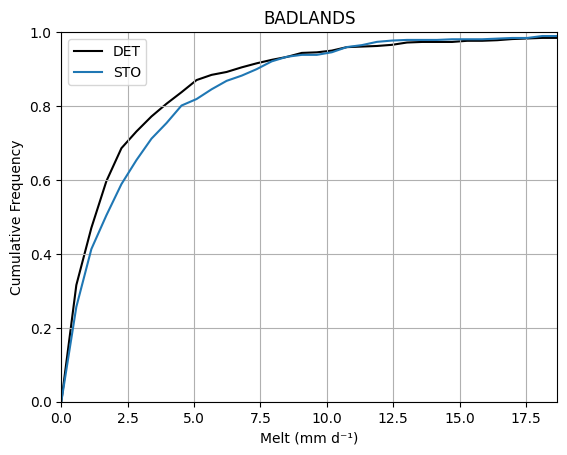

billings_deterministic.csv
billings_stochastic.csv


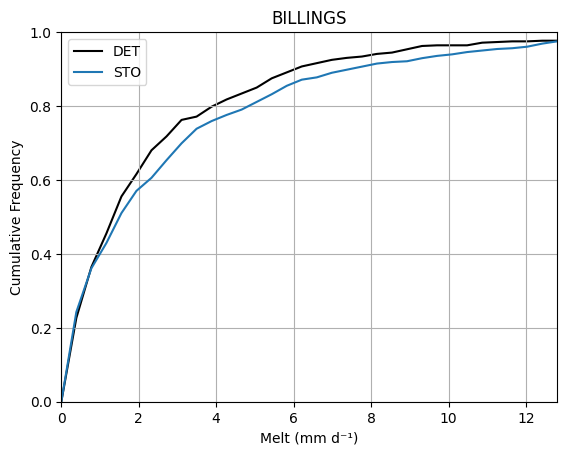

bismark_deterministic.csv
bismark_stochastic.csv


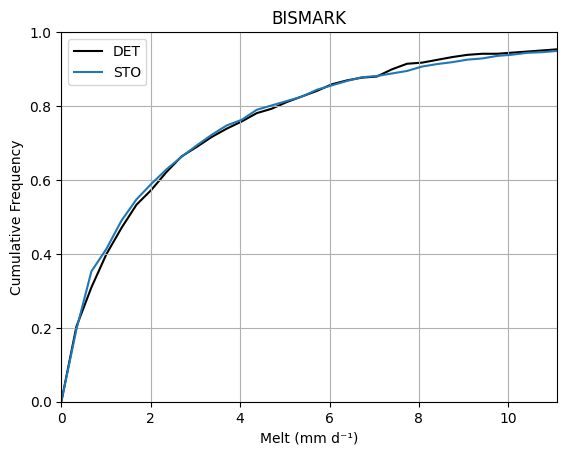

deerflat_deterministic.csv
deerflat_stochastic.csv


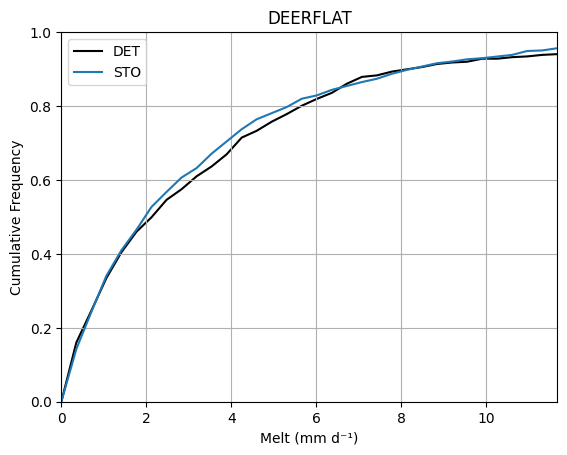

flagstaff_deterministic.csv
flagstaff_stochastic.csv


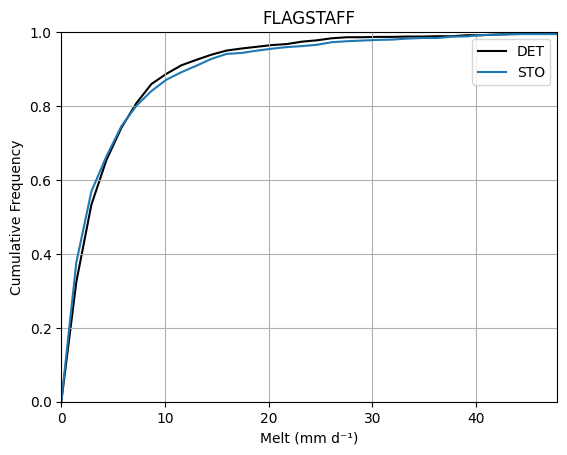

greatsaltlake_deterministic.csv
greatsaltlake_stochastic.csv


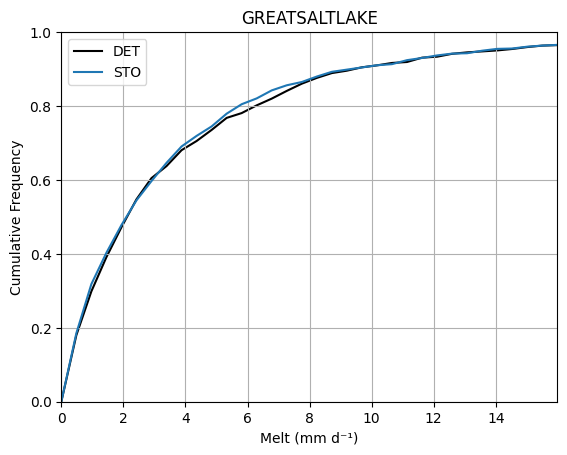

greeley_deterministic.csv
greeley_stochastic.csv


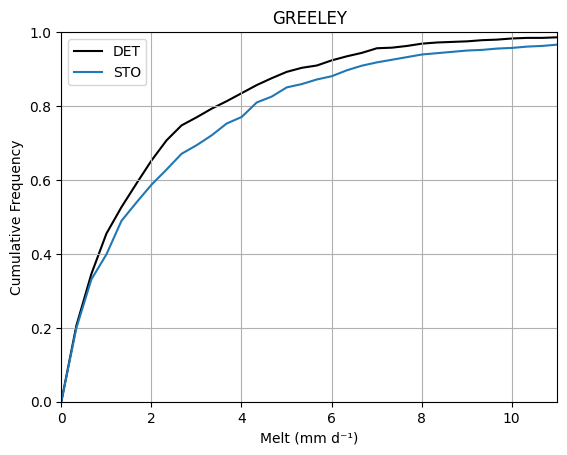

laramie_deterministic.csv
laramie_stochastic.csv


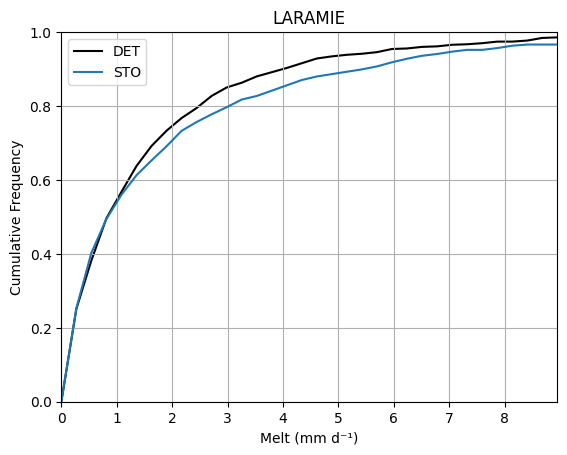

ogallala_deterministic.csv
ogallala_stochastic.csv


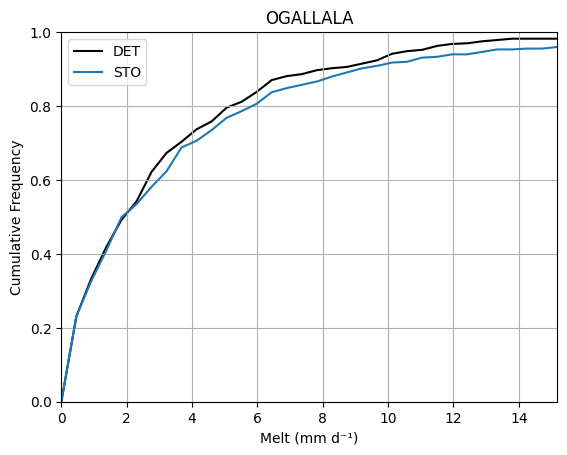

reno_deterministic.csv
reno_stochastic.csv


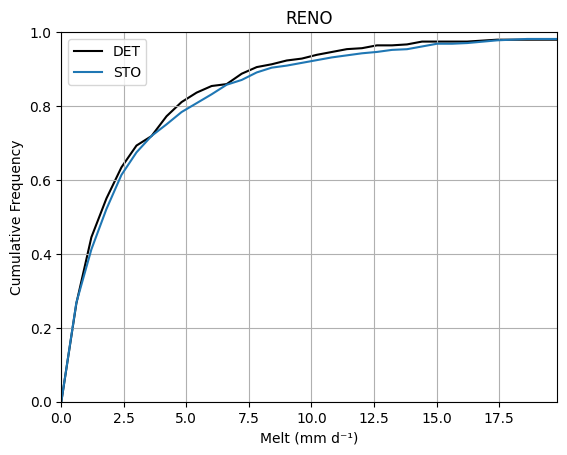

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import pandas as pd
from google.colab import data_table
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from decimal import Decimal


#fig, ax = plt.subplots()
#plt.rcParams['axes.grid'] = True


detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

print(detFiles)
print(stoFiles)

det_df = pd.read_csv(os.path.join(detFolder, detFiles[-1]))
#display(det_df)

for f_det, f_sto in zip(detFiles, stoFiles):

  print(f_det)
  det_df = pd.read_csv(os.path.join(detFolder, f_det))
  print(f_sto)
  sto_df = pd.read_csv(os.path.join(stoFolder, f_sto))

  df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])
  det_p = df['DET'].where(df['DET'] > 0.0).dropna()
  sto_p = df['STO'].where(df['STO'] > 0.0).dropna()

  #df_mask = df.mask(df == 0)
  #df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])

  #df.boxplot()
  #plt.title('Box and Whisker Plot using Pandas')
  #plt.ylabel('Values')
  #plt.show()


  max_value = max(max(det_p), max(sto_p))
  min_value = min(min(det_p), min(sto_p))

  bins_cdf = np.linspace(min_value, max_value, 101)

  det_h = np.array(np.histogram(det_p, bins_cdf)[0], float)
  sto_h = np.array(np.histogram(sto_p, bins_cdf)[0], float)

  det_cdf = np.array([0.0] + [sum(det_h[:i+1])/len(det_p) for i, value in enumerate(det_h)])
  sto_cdf = np.array([0.0] + [sum(sto_h[:i+1])/len(sto_p) for i, value in enumerate(sto_h)])

  det, = plt.plot(bins_cdf, det_cdf, color='black', zorder=-999)
  sto, = plt.plot(bins_cdf, sto_cdf)

  plt.title(f_det.split('_')[0].upper())
  plt.legend([det, sto], ['DET', 'STO'])
  plt.xlim(0, 0.33*max_value)
  plt.ylim(0, 1.0)
  plt.ylabel('Cumulative Frequency')
  plt.xlabel('Melt (mm d⁻¹)')
  plt.show()
  plt.clf()



In [ ]:
%reset -f

['badlands_deterministic.csv', 'billings_deterministic.csv', 'bismark_deterministic.csv', 'deerflat_deterministic.csv', 'flagstaff_deterministic.csv', 'greatsaltlake_deterministic.csv', 'greeley_deterministic.csv', 'laramie_deterministic.csv', 'ogallala_deterministic.csv', 'reno_deterministic.csv']
['badlands_stochastic.csv', 'billings_stochastic.csv', 'bismark_stochastic.csv', 'deerflat_stochastic.csv', 'flagstaff_stochastic.csv', 'greatsaltlake_stochastic.csv', 'greeley_stochastic.csv', 'laramie_stochastic.csv', 'ogallala_stochastic.csv', 'reno_stochastic.csv']
badlands_deterministic.csv
badlands_stochastic.csv


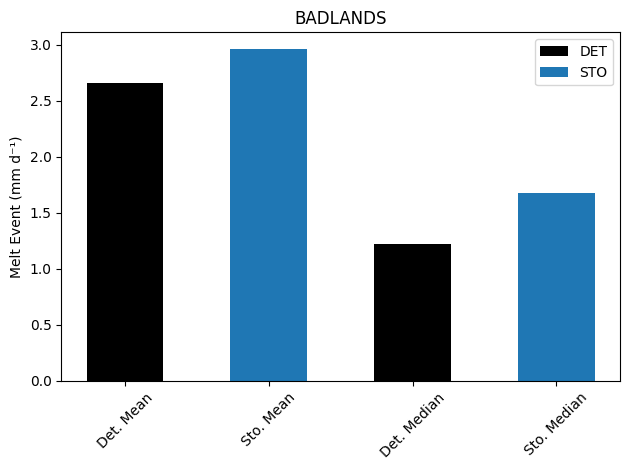

billings_deterministic.csv
billings_stochastic.csv


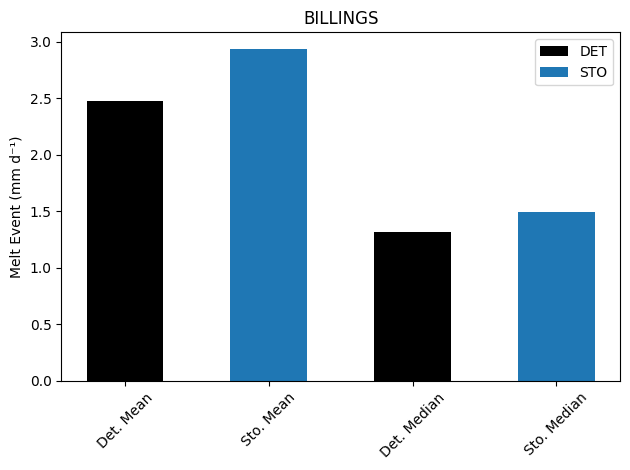

bismark_deterministic.csv
bismark_stochastic.csv


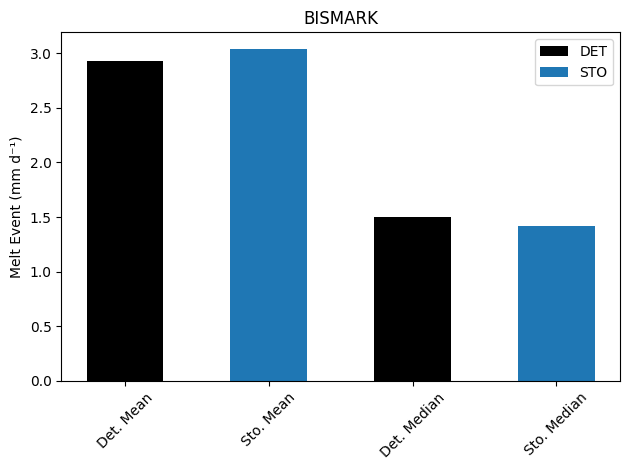

deerflat_deterministic.csv
deerflat_stochastic.csv


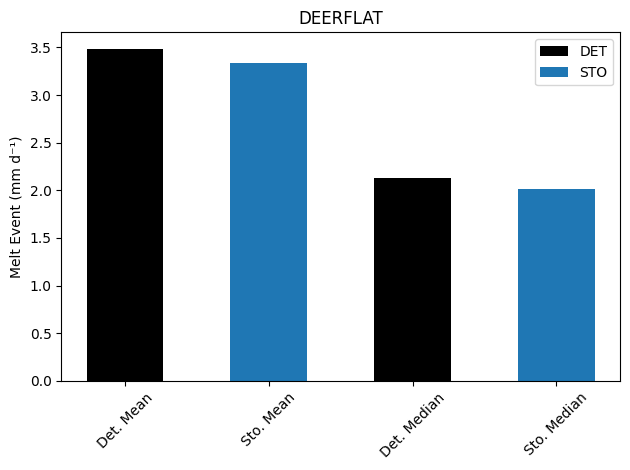

flagstaff_deterministic.csv
flagstaff_stochastic.csv


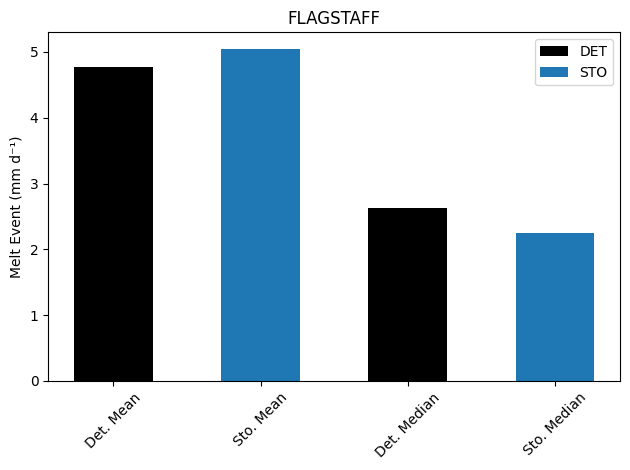

greatsaltlake_deterministic.csv
greatsaltlake_stochastic.csv


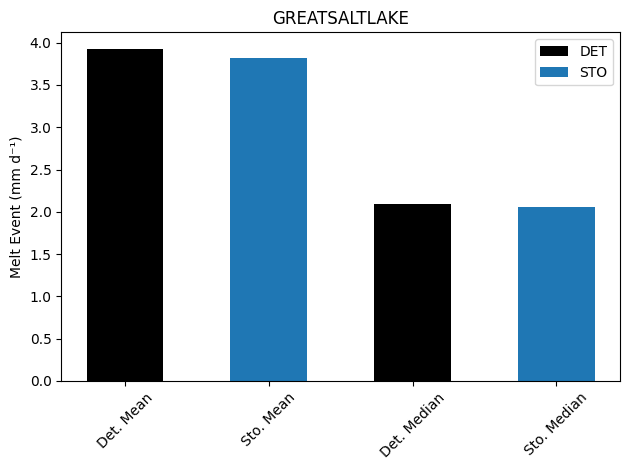

greeley_deterministic.csv
greeley_stochastic.csv


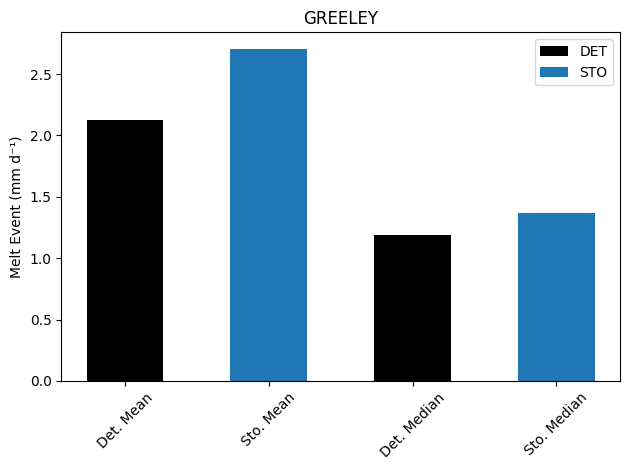

laramie_deterministic.csv
laramie_stochastic.csv


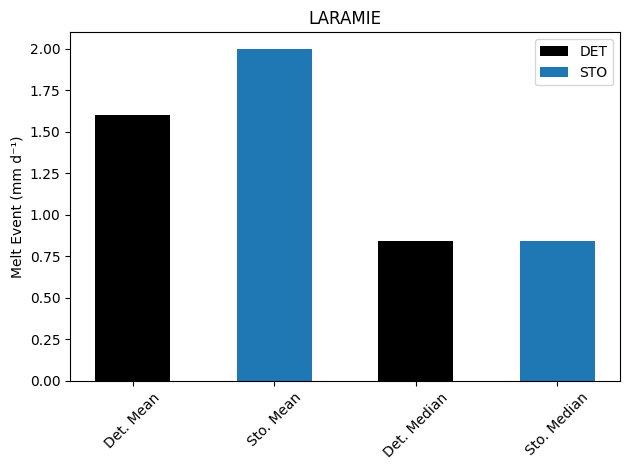

ogallala_deterministic.csv
ogallala_stochastic.csv


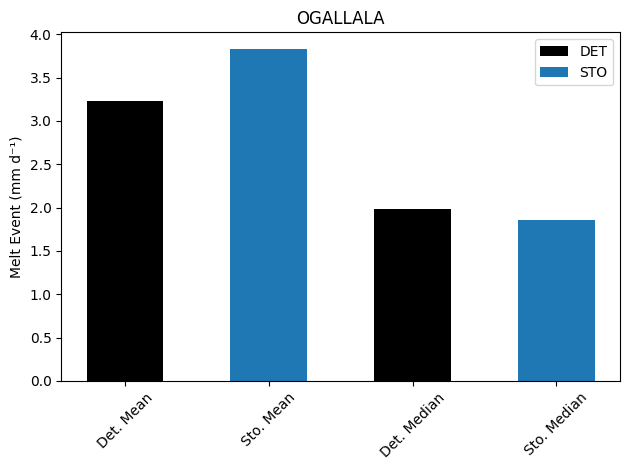

reno_deterministic.csv
reno_stochastic.csv


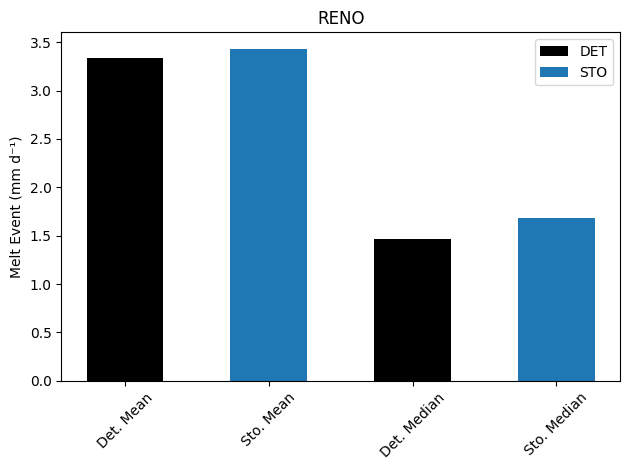

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import pandas as pd
from google.colab import data_table
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from decimal import Decimal

#fig, ax = plt.subplots()
#plt.rcParams['axes.grid'] = True


detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

print(detFiles)
print(stoFiles)


#plt.gca().set_aspect(3)

for f_det, f_sto in zip(detFiles, stoFiles):

  print(f_det)
  det_df = pd.read_csv(os.path.join(detFolder, f_det))
  print(f_sto)
  sto_df = pd.read_csv(os.path.join(stoFolder, f_sto))

  df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])
  det_p = df['DET'].where(df['DET'] > 0.0).dropna()
  sto_p = df['STO'].where(df['STO'] > 0.0).dropna()

  #df_mask = df.mask(df == 0)
  #df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])

  plt.title(f_det.split('_')[0].upper())
  det_avg = det_p.mean()
  sto_avg = sto_p.mean()
  det_med = det_p.median()
  sto_med = sto_p.median()

  det = plt.bar([0.5, 3.5], [det_avg, det_med], color='black', zorder=-999)
  sto = plt.bar([2, 5], [sto_avg, sto_med])

  plt.legend([det, sto], ['DET', 'STO'])
  #plt.xlim(0, 0.33*max_value)
  labels = ['Det. Mean', 'Sto. Mean', 'Det. Median', 'Sto. Median']
  plt.xticks([0.5, 2, 3.5, 5], labels=labels, rotation=45)

  #plt.ylim(0, 1.0)
  plt.ylabel('Melt Event (mm d⁻¹)')
  plt.xlabel('')

  plt.grid(False)
  plt.tight_layout()
  plt.show()
  plt.clf()


In [ ]:
%reset -f

['badlands_deterministic.csv', 'billings_deterministic.csv', 'bismark_deterministic.csv', 'deerflat_deterministic.csv', 'flagstaff_deterministic.csv', 'greatsaltlake_deterministic.csv', 'greeley_deterministic.csv', 'laramie_deterministic.csv', 'ogallala_deterministic.csv', 'reno_deterministic.csv']
['badlands_stochastic.csv', 'billings_stochastic.csv', 'bismark_stochastic.csv', 'deerflat_stochastic.csv', 'flagstaff_stochastic.csv', 'greatsaltlake_stochastic.csv', 'greeley_stochastic.csv', 'laramie_stochastic.csv', 'ogallala_stochastic.csv', 'reno_stochastic.csv']
badlands_deterministic.csv
badlands_stochastic.csv


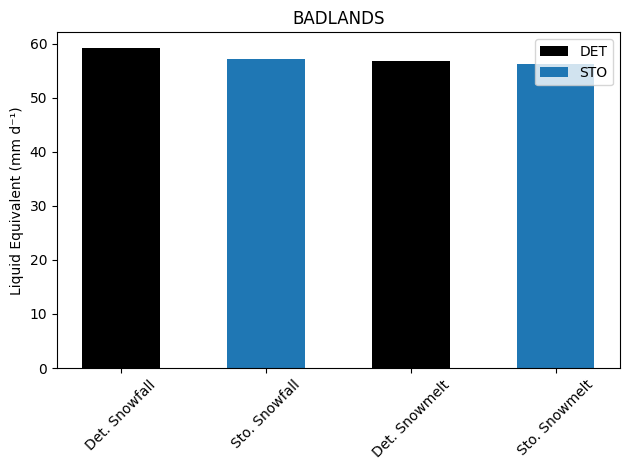

billings_deterministic.csv
billings_stochastic.csv


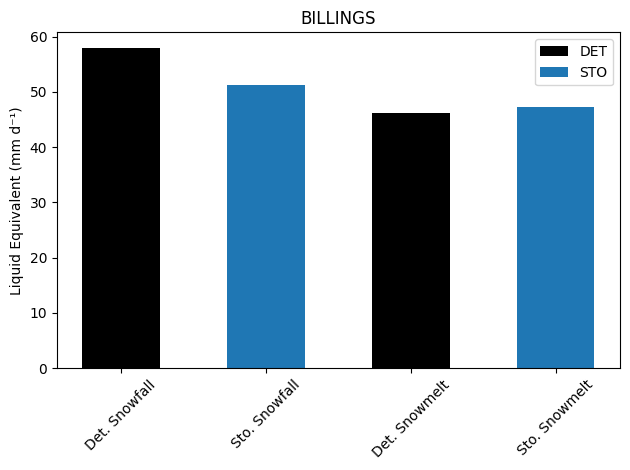

bismark_deterministic.csv
bismark_stochastic.csv


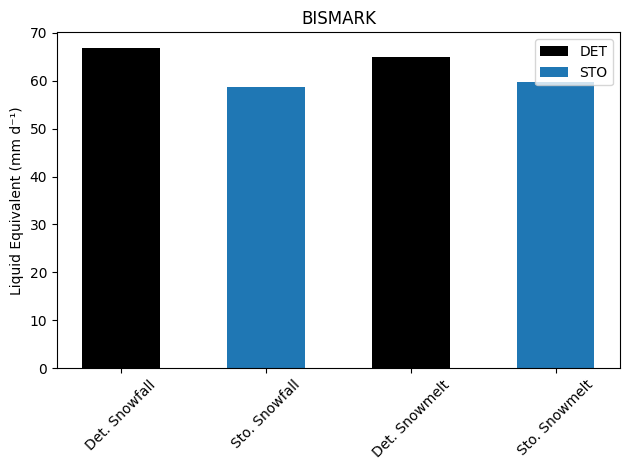

deerflat_deterministic.csv
deerflat_stochastic.csv


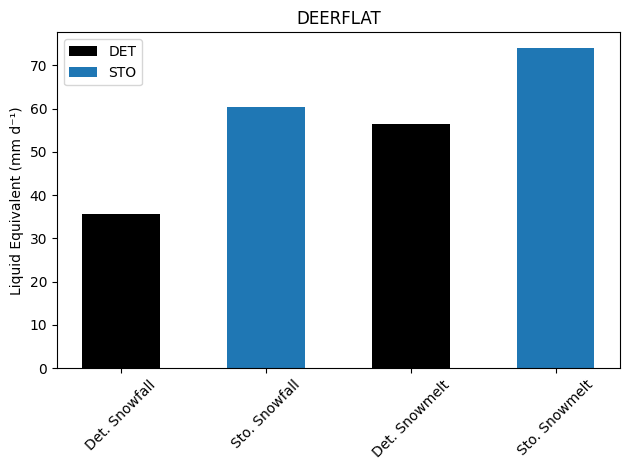

flagstaff_deterministic.csv
flagstaff_stochastic.csv


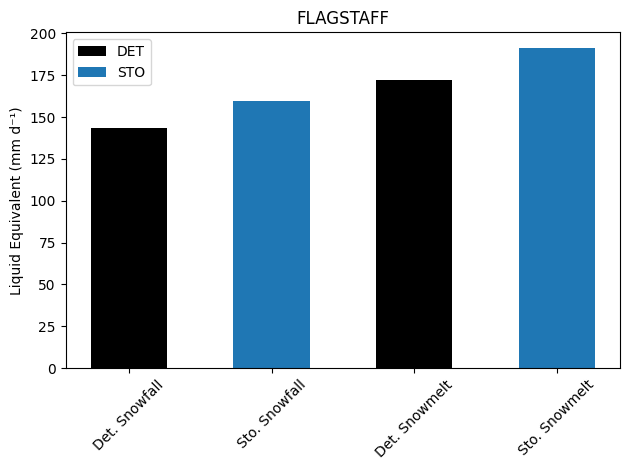

greatsaltlake_deterministic.csv
greatsaltlake_stochastic.csv


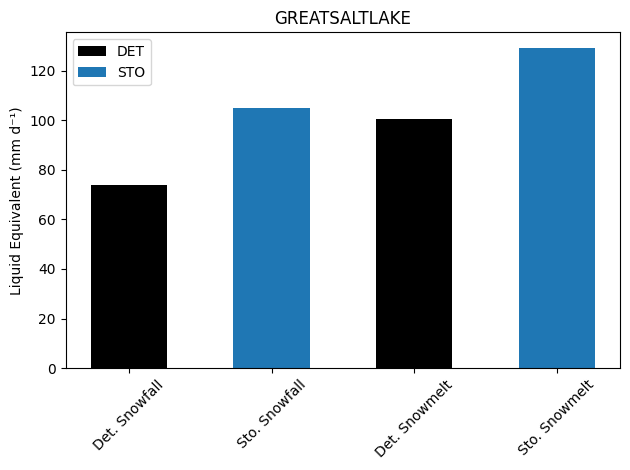

greeley_deterministic.csv
greeley_stochastic.csv


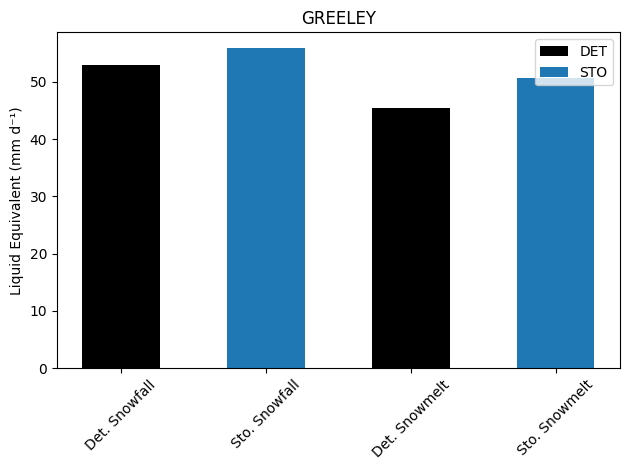

laramie_deterministic.csv
laramie_stochastic.csv


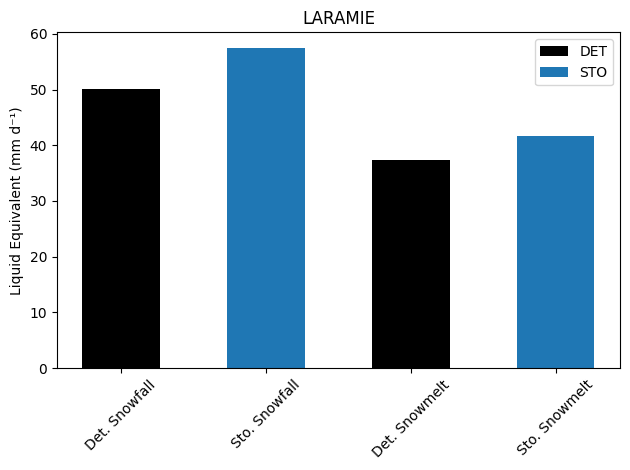

ogallala_deterministic.csv
ogallala_stochastic.csv


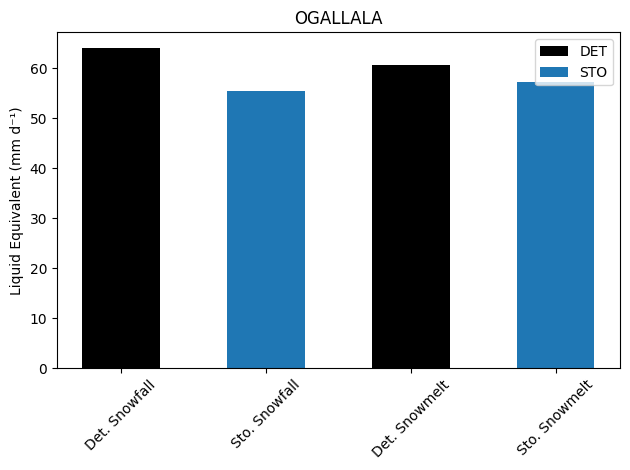

reno_deterministic.csv
reno_stochastic.csv


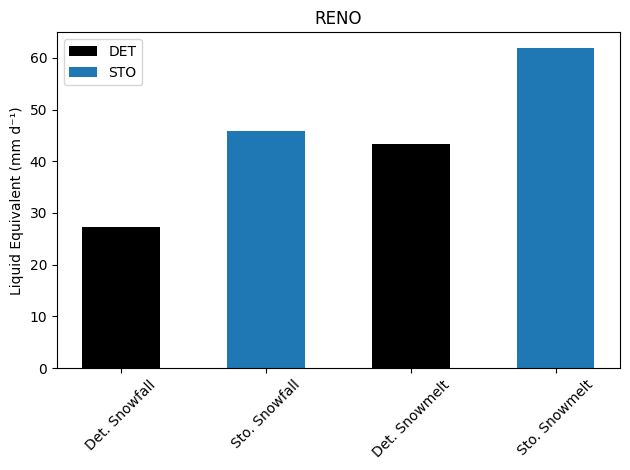

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import pandas as pd
from google.colab import data_table
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from decimal import Decimal



detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

print(detFiles)
print(stoFiles)



  # print('-----STOCHASTIC------')
  # print('Total: ', sto_df['Rainfall Off Snow (mm)'].sum()/30.0 + sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0)
  # #print('SWEbal: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0 - sto_df['Snowmelt (mm)'].sum()/30.0 - sto_df['Sublimation (mm)'].sum()/30.0)
  # print('Fall: ', sto_df['Snowfall (mm)'].sum()/30.0)
  # print('Melt: ', sto_df['Snowmelt (mm)'].sum()/30.0)
  # print('RoS: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0)
  # print('Subl: ', sto_df['Sublimation (mm)'].sum()/30.0)



for f_det, f_sto in zip(detFiles, stoFiles):

  print(f_det)
  det_df = pd.read_csv(os.path.join(detFolder, f_det))
  print(f_sto)
  sto_df = pd.read_csv(os.path.join(stoFolder, f_sto))

  df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])
  det_p = df['DET'].where(df['DET'] > 0.0).dropna()
  sto_p = df['STO'].where(df['STO'] > 0.0).dropna()

  det_sno = det_df['Snowfall (mm)'].sum()/30.0
  sto_sno = sto_df['Snowfall (mm)'].sum()/30.0
  #det_cnt = (det_df['Snowmelt (mm)'] > 0).sum()/30.0
  #sto_cnt = (sto_df['Snowmelt (mm)'] > 0).sum()/30.0
  det_cnt = det_df['Snowmelt (mm)'].sum()/30.0
  sto_cnt = sto_df['Snowmelt (mm)'].sum()/30.0

  plt.title(f_det.split('_')[0].upper())

  det = plt.bar([0.5, 3.5], [det_sno, det_cnt], color='black', zorder=-999)
  sto = plt.bar([2, 5], [sto_sno, sto_cnt])

  plt.legend([det, sto], ['DET', 'STO'])
  #plt.xlim(0, 0.33*max_value)
  labels = ['Det. Snowfall', 'Sto. Snowfall', 'Det. Snowmelt', 'Sto. Snowmelt']
  plt.xticks([0.5, 2, 3.5, 5], labels=labels, rotation=45)

  #plt.ylim(0, 1.0)
  plt.ylabel('Liquid Equivalent (mm d⁻¹)')
  plt.xlabel('')

  plt.grid(False)
  plt.tight_layout()
  plt.show()
  plt.clf()




In [ ]:
%reset -f

['badlands_deterministic.csv', 'billings_deterministic.csv', 'bismark_deterministic.csv', 'deerflat_deterministic.csv', 'flagstaff_deterministic.csv', 'greatsaltlake_deterministic.csv', 'greeley_deterministic.csv', 'laramie_deterministic.csv', 'ogallala_deterministic.csv', 'reno_deterministic.csv']
['badlands_stochastic.csv', 'billings_stochastic.csv', 'bismark_stochastic.csv', 'deerflat_stochastic.csv', 'flagstaff_stochastic.csv', 'greatsaltlake_stochastic.csv', 'greeley_stochastic.csv', 'laramie_stochastic.csv', 'ogallala_stochastic.csv', 'reno_stochastic.csv']
badlands_deterministic.csv
badlands_stochastic.csv


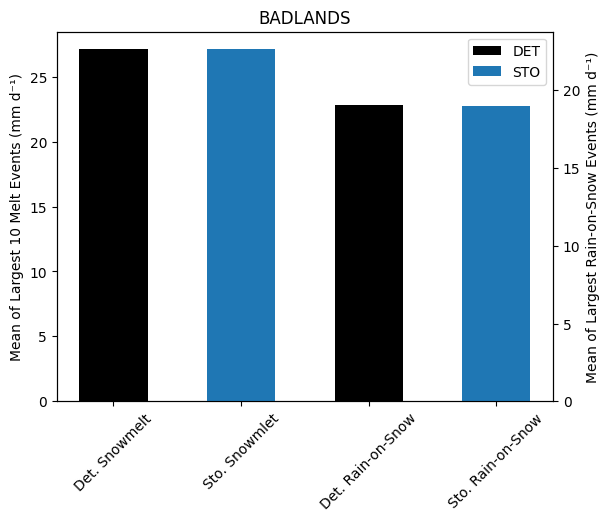

billings_deterministic.csv
billings_stochastic.csv


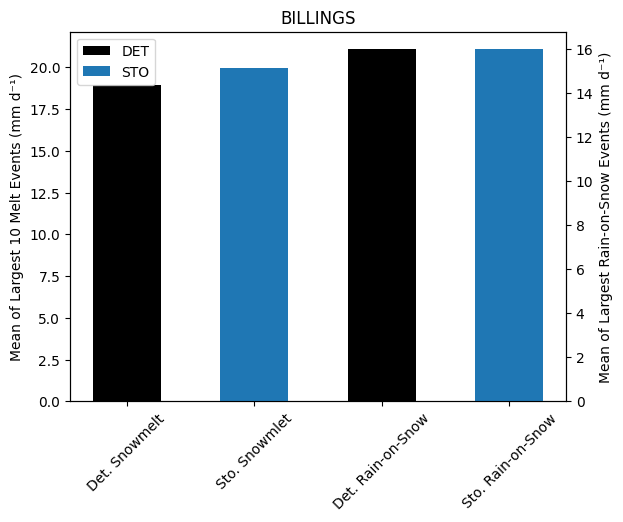

bismark_deterministic.csv
bismark_stochastic.csv


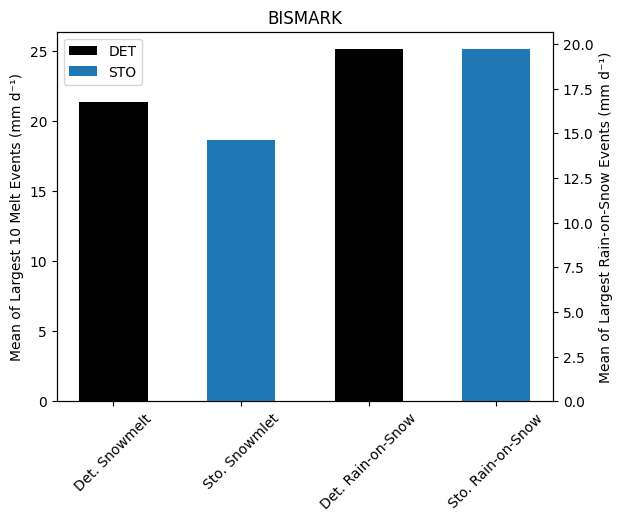

deerflat_deterministic.csv
deerflat_stochastic.csv


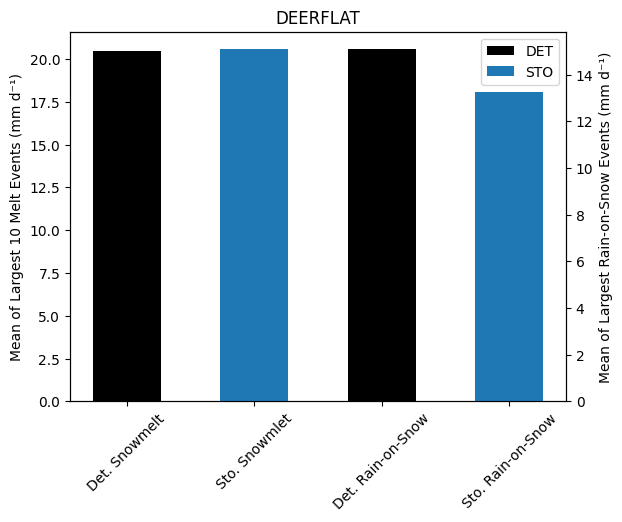

flagstaff_deterministic.csv
flagstaff_stochastic.csv


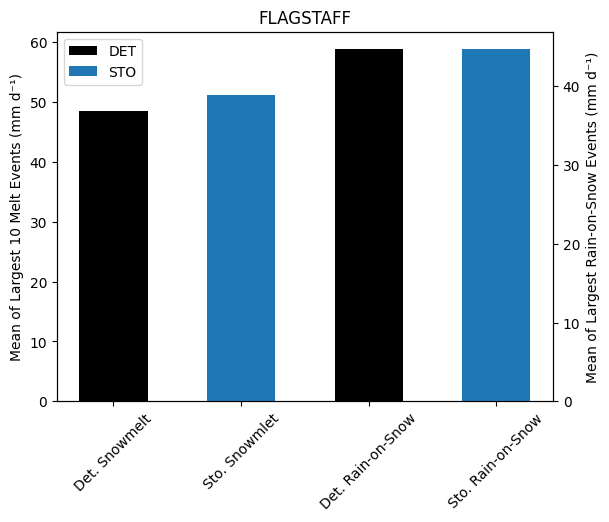

greatsaltlake_deterministic.csv
greatsaltlake_stochastic.csv


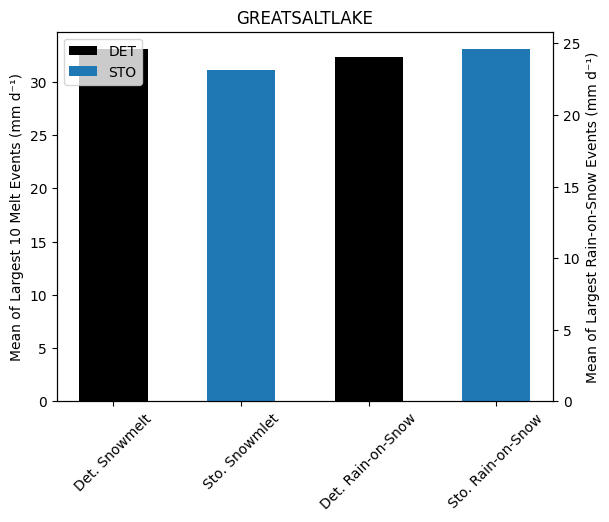

greeley_deterministic.csv
greeley_stochastic.csv


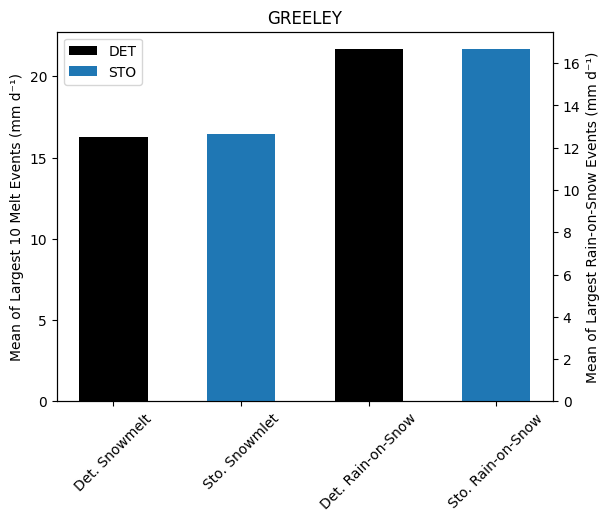

laramie_deterministic.csv
laramie_stochastic.csv


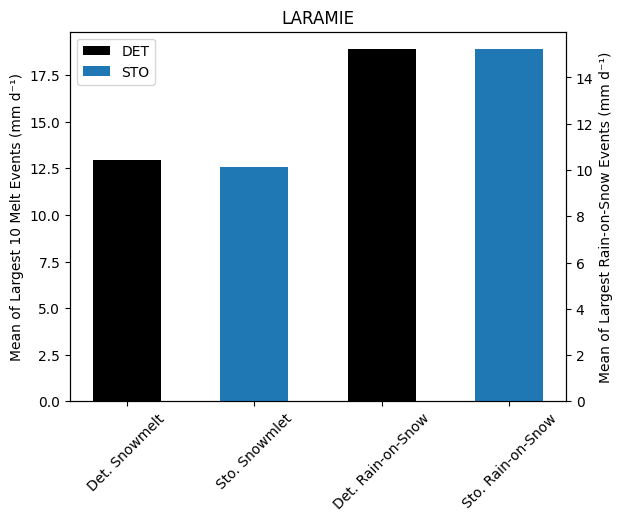

ogallala_deterministic.csv
ogallala_stochastic.csv


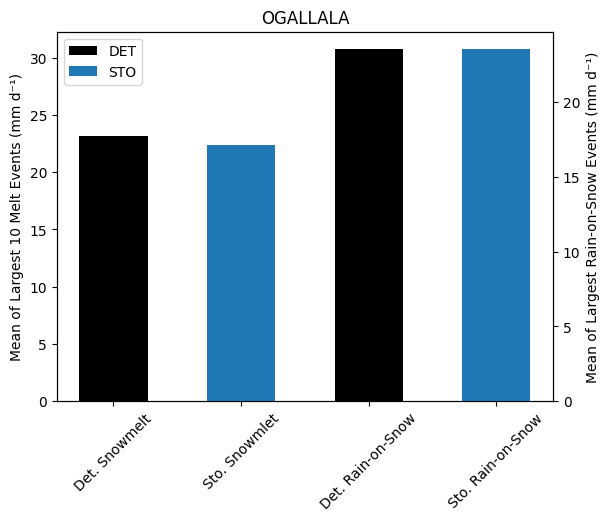

reno_deterministic.csv
reno_stochastic.csv


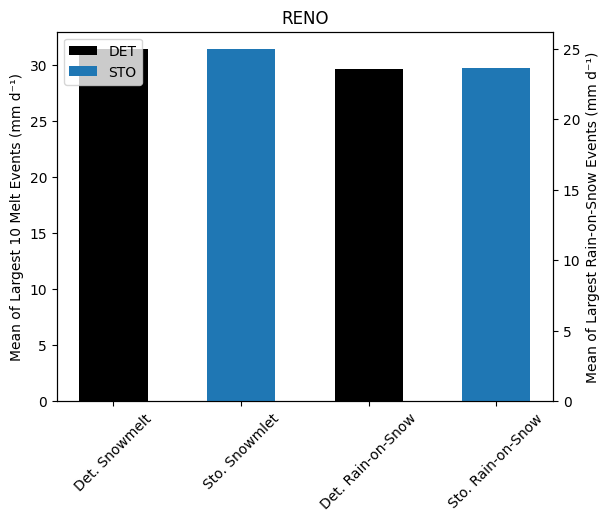

In [ ]:
import os
import pandas as pd
from google.colab import data_table
import numpy as np
import scipy
from scipy.spatial import distance
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
from decimal import Decimal



detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = os.listdir(detFolder)
stoFiles = os.listdir(stoFolder)

print(detFiles)
print(stoFiles)



  # print('-----STOCHASTIC------')
  # print('Total: ', sto_df['Rainfall Off Snow (mm)'].sum()/30.0 + sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0)
  # #print('SWEbal: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0 + sto_df['Snowfall (mm)'].sum()/30.0 - sto_df['Snowmelt (mm)'].sum()/30.0 - sto_df['Sublimation (mm)'].sum()/30.0)
  # print('Fall: ', sto_df['Snowfall (mm)'].sum()/30.0)
  # print('Melt: ', sto_df['Snowmelt (mm)'].sum()/30.0)
  # print('RoS: ', sto_df['Rainfall On Snow (mm)'].sum()/30.0)
  # print('Subl: ', sto_df['Sublimation (mm)'].sum()/30.0)



for f_det, f_sto in zip(detFiles, stoFiles):

  fig = plt.figure() # Create matplotlib figure

  ax = fig.add_subplot(111) # Create matplotlib axes
  ax2 = ax.twinx() # Create another axes that shares the same x-axis as ax.
  ax.grid(False)
  ax2.grid(False)

  print(f_det)
  det_df = pd.read_csv(os.path.join(detFolder, f_det))
  print(f_sto)
  sto_df = pd.read_csv(os.path.join(stoFolder, f_sto))

  df = pd.DataFrame(data=np.array([det_df['Snowmelt (mm)'].to_list(), sto_df['Snowmelt (mm)'].to_list()]).transpose(), columns=['DET', 'STO'])
  det_p = df['DET'].where(df['DET'] > 0.0).dropna()
  sto_p = df['STO'].where(df['STO'] > 0.0).dropna()

  det_mlt = det_df['Snowmelt (mm)'].nlargest(10).mean()
  sto_mlt = sto_df['Snowmelt (mm)'].nlargest(10).mean()
  det_ros = det_df['Rainfall On Snow (mm)'].nlargest(10).mean()
  sto_ros = sto_df['Rainfall On Snow (mm)'].nlargest(10).mean()

  det = ax.bar([0.5, 3.5], [det_mlt, sto_mlt], color=['black', 'black'])
  sto = ax2.bar([2, 5], [det_ros, sto_ros], color=['tab:blue', 'tab:blue'])

  ax2.set_title(f_det.split('_')[0].upper())

  plt.legend([det, sto], ['DET', 'STO'])
  labels = ['Det. Snowmelt', 'Sto. Snowmelt', 'Det. Rain-on-Snow', 'Sto. Rain-on-Snow']
  ax.set_xticks([0.5, 2, 3.5, 5], labels=labels, rotation=45)


  ax.set_ylabel('Mean of Largest 10 Melt Events (mm d⁻¹)')
  ax2.set_ylabel('Mean of Largest Rain-on-Snow Events (mm d⁻¹)')

  plt.show()

In [ ]:

import numpy as np
import os
import pandas as pd

detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/stochastic'

detFiles = list(sorted(os.listdir(detFolder)))
stoFiles = list(sorted(os.listdir(stoFolder)))

hdr_str = 'i,Year,Month,Day,Precip(mm),Max(C),Min(C),Dew(C),Solrad(L/d),Wind(m/s)'
hdr_row = hdr_str.split(',')

for i in range(10):
  print(detFiles[i])
  det_fpath = os.path.join(detFolder, detFiles[i])
  sto_fpath = os.path.join(stoFolder, stoFiles[i])

  with open(det_fpath) as f_det:
    det_lines = f_det.readlines()[1:]

  with open(sto_fpath) as f_sto:
    sto_lines = f_sto.readlines()[1:]

  det = []
  for l in det_lines:
    row = l.strip('\n').split(',')
    det.append(row)

  sto = []
  for l in sto_lines:
    row = l.strip('\n').split(',')
    sto.append(row)

  det_df = pd.DataFrame(data=det, columns=hdr_row).astype(float)
  sto_df = pd.DataFrame(data=sto, columns=hdr_row).astype(float)

  det_df['Avg(C)'] = ((det_df['Max(C)'] - det_df['Min(C)']).divide(2.0)) + (det_df['Min(C)'])
  sto_df['Avg(C)'] = ((sto_df['Max(C)'] - sto_df['Min(C)']).divide(2.0)) + (sto_df['Min(C)'])

  det_df['Snowfall(mm)'] = np.where(det_df['Avg(C)'] < 0.0, det_df['Precip(mm)'], 0.0)
  det_snowfall = det_df['Snowfall(mm)'].sum()/30.0

  sto_df['Snowfall(mm)'] = np.where(sto_df['Avg(C)'] < 0.0, sto_df['Precip(mm)'], 0.0)
  sto_snowfall = sto_df['Snowfall(mm)'].sum()/30.0

  print('Det snowfall: ', det_snowfall)
  print('Sto snowfall: ', sto_snowfall)



display(det_df)




badlands.csv
Det snowfall:  47.78666666666666
Sto snowfall:  46.446666666666665
billings.csv
Det snowfall:  43.36
Sto snowfall:  38.07333333333333
bismark.csv
Det snowfall:  51.720000000000006
Sto snowfall:  48.99666666666666
deerflat.csv
Det snowfall:  22.780000000000005
Sto snowfall:  42.45333333333333
flagstaff.csv
Det snowfall:  79.86333333333333
Sto snowfall:  126.78999999999999
greatsaltlake.csv
Det snowfall:  43.98666666666667
Sto snowfall:  75.69666666666667
greeley.csv
Det snowfall:  40.080000000000005
Sto snowfall:  39.169999999999995
laramie.csv
Det snowfall:  36.43999999999999
Sto snowfall:  44.94666666666667
ogallala.csv
Det snowfall:  42.72
Sto snowfall:  42.29333333333334
reno.csv
Det snowfall:  15.806666666666668
Sto snowfall:  31.203333333333337


,i,Year,Month,Day,Precip(mm),Max(C),Min(C),Dew(C),Solrad(L/d),Wind(m/s),Avg(C),Snowfall(mm)
0,0.0,1984.0,1.0,1.0,0.0,6.70,-2.28,-1.39,129.48,0.0,2.210,0.0
1,1.0,1984.0,1.0,2.0,0.0,3.85,-1.39,-3.19,113.57,5.1,1.230,0.0
2,2.0,1984.0,1.0,3.0,0.0,0.15,-1.33,-4.49,175.23,0.0,-0.590,0.0
3,3.0,1984.0,1.0,4.0,0.0,3.23,-2.18,-4.37,151.49,0.0,0.525,0.0
4,4.0,1984.0,1.0,5.0,0.0,1.28,-1.75,-3.44,147.80,0.0,-0.235,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
10953,10953.0,2013.0,12.0,27.0,0.0,7.80,-5.65,-4.68,158.91,0.0,1.075,0.0
10954,10954.0,2013.0,12.0,28.0,0.0,4.07,-6.14,-6.14,188.13,5.5,-1.035,0.0
10955,10955.0,2013.0,12.0,29.0,0.0,8.77,-6.70,-6.44,175.13,1.8,1.035,0.0
10956,10956.0,2013.0,12.0,30.0,0.0,6.59,-6.78,-5.82,177.36,4.2,-0.095,0.0


In [13]:
data = {'col1': [3, -1, 0, 5, 2, -4, 1]}
df = pd.DataFrame(data)

# Count items greater than zero in 'col1'
count_greater_than_zero = (df['col1'] > 0).sum()
print(count_greater_than_zero)

4


In [24]:
%reset -f

,year,month,day,Rainfall Off Snow (mm),Rainfall On Snow (mm),Snowfall (mm),End of Day SWE (mm),Sublimation (mm),Snowmelt (mm),Net Water Input (mm),Ice Fraction,Saturation Fraction
0,1984.0,1.0,16.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.25
1,1984.0,1.0,17.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.25
2,1984.0,1.0,18.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.25
3,1984.0,1.0,19.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.25
4,1984.0,1.0,20.0,0.0,0.0,0.0,0.000,0.000,0.0,0.0,0.0,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...
10938,2013.0,12.0,27.0,0.0,0.0,0.0,13.244,0.653,0.0,0.0,0.0,0.25
10939,2013.0,12.0,28.0,0.0,0.0,0.0,12.694,0.550,0.0,0.0,0.0,0.25
10940,2013.0,12.0,29.0,0.0,0.0,0.0,12.611,0.083,0.0,0.0,0.0,0.25
10941,2013.0,12.0,30.0,0.0,0.0,0.0,12.480,0.131,0.0,0.0,0.0,0.25


badlands_deterministic.csv
badlands_stochastic.csv
billings_deterministic.csv
billings_stochastic.csv
bismark_deterministic.csv
bismark_stochastic.csv
deerflat_deterministic.csv
deerflat_stochastic.csv
flagstaff_deterministic.csv
flagstaff_stochastic.csv
greatsaltlake_deterministic.csv
greatsaltlake_stochastic.csv
greeley_deterministic.csv
greeley_stochastic.csv
laramie_deterministic.csv
laramie_stochastic.csv
ogallala_deterministic.csv
ogallala_stochastic.csv
reno_deterministic.csv
reno_stochastic.csv


<ipython-input-68-69afd3044cf5>:96: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


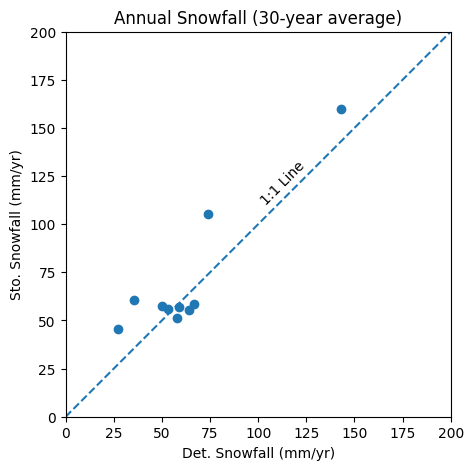

<ipython-input-68-69afd3044cf5>:109: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


<Figure size 640x480 with 0 Axes>

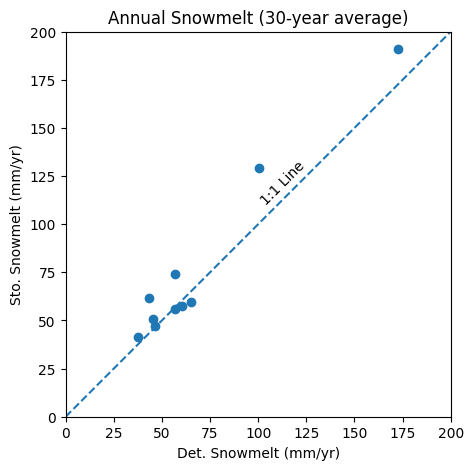

<ipython-input-68-69afd3044cf5>:122: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


<Figure size 640x480 with 0 Axes>

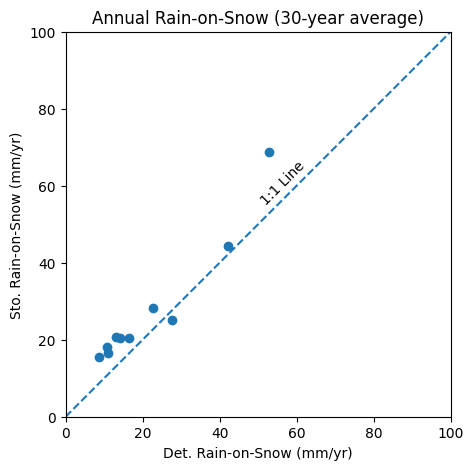

<ipython-input-68-69afd3044cf5>:135: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


<Figure size 640x480 with 0 Axes>

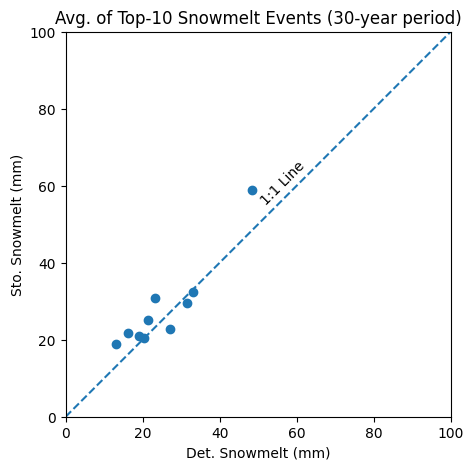

<ipython-input-68-69afd3044cf5>:148: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


<Figure size 640x480 with 0 Axes>

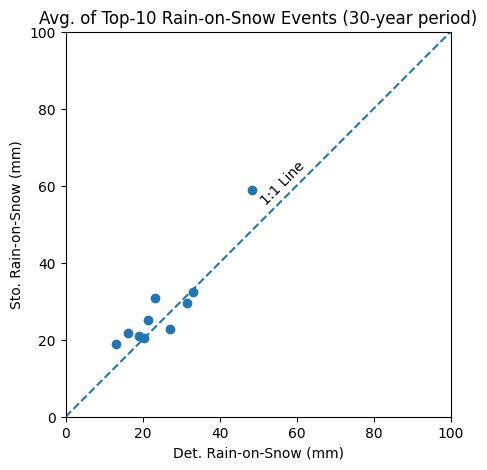

<ipython-input-68-69afd3044cf5>:161: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)


<Figure size 640x480 with 0 Axes>

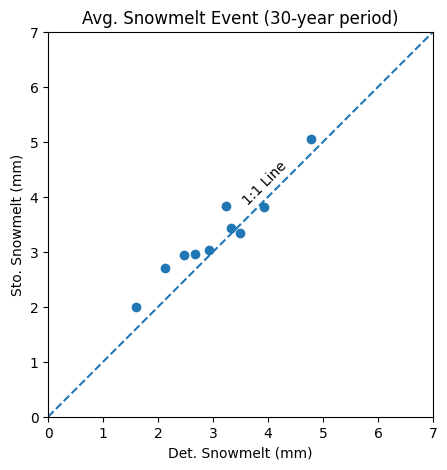

<Figure size 640x480 with 0 Axes>

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


detFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/deterministic'
stoFolder = '/content/drive/My Drive/Colab Notebooks/TeamProjects/10_GHCN_RHEMSNOW/snow_output/stochastic'

detFiles = list(sorted(os.listdir(detFolder)))
stoFiles = list(sorted(os.listdir(stoFolder)))

hdr_str = 'year,month,day,Rainfall Off Snow (mm),Rainfall On Snow (mm),Snowfall (mm),End of Day SWE (mm),Sublimation (mm),Snowmelt (mm),Net Water Input (mm),Ice Fraction,Saturation Fraction'
hdr_row = hdr_str.split(',')

det_fpath = os.path.join(detFolder, detFiles[0])
with open(det_fpath) as f_det:
  det_lines = f_det.readlines()[1:]

det = []
for l in det_lines:
  row = l.strip('\n').split(',')
  det.append(row)

det_df = pd.DataFrame(data=det, columns=hdr_row).astype(float)

display(det_df)

# det_snowfall
# det_snowmelt
# det_RoS
# det_


det_snowfall = []
det_snowmelt = []
det_RoS = []
det_topmelt = []
det_topRoS = []
det_avgmelt = []

sto_snowfall = []
sto_snowmelt = []
sto_RoS = []
sto_topmelt = []
sto_topRoS = []
sto_avgmelt = []

for i in range(10):

  print(detFiles[i])
  print(stoFiles[i])
  det_fpath = os.path.join(detFolder, detFiles[i])
  sto_fpath = os.path.join(stoFolder, stoFiles[i])

  with open(det_fpath) as f_det:
    det_lines = f_det.readlines()[1:]

  with open(sto_fpath) as f_sto:
    sto_lines = f_sto.readlines()[1:]

  det = []
  for l in det_lines:
    row = l.strip('\n').split(',')
    det.append(row)

  sto = []
  for l in sto_lines:
    row = l.strip('\n').split(',')
    sto.append(row)

  det_df = pd.DataFrame(data=det, columns=hdr_row).astype(float)
  sto_df = pd.DataFrame(data=sto, columns=hdr_row).astype(float)

  det_snowfall.append(det_df['Snowfall (mm)'].sum()/30.0)
  det_snowmelt.append(det_df['Snowmelt (mm)'].sum()/30.0)
  det_RoS.append(det_df['Rainfall On Snow (mm)'].sum()/30.0)
  det_topmelt.append(det_df['Snowmelt (mm)'].nlargest(10).mean())
  det_topRoS.append(det_df['Rainfall On Snow (mm)'].nlargest(10).mean())
  det_avgmelt.append(det_df['Snowmelt (mm)'].where(det_df['Snowmelt (mm)'] > 0.0).dropna().mean())

  sto_snowfall.append(sto_df['Snowfall (mm)'].sum()/30.0)
  sto_snowmelt.append(sto_df['Snowmelt (mm)'].sum()/30.0)
  sto_RoS.append(sto_df['Rainfall On Snow (mm)'].sum()/30.0)
  sto_topmelt.append(sto_df['Snowmelt (mm)'].nlargest(10).mean())
  sto_topRoS.append(sto_df['Rainfall On Snow (mm)'].nlargest(10).mean())
  sto_avgmelt.append(sto_df['Snowmelt (mm)'].where(sto_df['Snowmelt (mm)'] > 0.0).dropna().mean())




plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Annual Snowfall (30-year average)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_snowfall, sto_snowfall)
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.xlabel('Det. Snowfall (mm/yr)')
plt.ylabel('Sto. Snowfall (mm/yr)')
plt.show()
plt.clf()

plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Annual Snowmelt (30-year average)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_snowmelt, sto_snowmelt)
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.xlabel('Det. Snowmelt (mm/yr)')
plt.ylabel('Sto. Snowmelt (mm/yr)')
plt.show()
plt.clf()

plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Annual Rain-on-Snow (30-year average)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_RoS, sto_RoS)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Det. Rain-on-Snow (mm/yr)')
plt.ylabel('Sto. Rain-on-Snow (mm/yr)')
plt.show()
plt.clf()

plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Avg. of Top-10 Snowmelt Events (30-year period)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_topmelt, sto_topmelt)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Det. Snowmelt (mm)')
plt.ylabel('Sto. Snowmelt (mm)')
plt.show()
plt.clf()

plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Avg. of Top-10 Rain-on-Snow Events (30-year period)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_topmelt, sto_topmelt)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel('Det. Rain-on-Snow (mm)')
plt.ylabel('Sto. Rain-on-Snow (mm)')
plt.show()
plt.clf()

plt.figure(figsize=(5, 5))
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Avg. Snowmelt Event (30-year period)')
plt.plot([0, 200], [0, 200], linestyle='--')
plt.annotate('1:1 Line', [0.5, 0.55], textcoords='axes fraction', rotation=45)
plt.scatter(det_avgmelt, sto_avgmelt)
plt.xlim(0, 7)
plt.ylim(0, 7)
plt.xlabel('Det. Snowmelt (mm)')
plt.ylabel('Sto. Snowmelt (mm)')
plt.show()
plt.clf()




